In [34]:
from keras import layers, models, optimizers
from keras.metrics import AUC

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [35]:
PATH_DATASET = "DS_EURUSD/M5/2/"
DATASET_FILE_NAME = f"{PATH_DATASET}dataset_EURUSD_M5_ALL.csv"

# Основной режим обучения:
#   "classification" -> обучаем модель предсказывать Target1, то есть направление 0/1.
#   "regression"     -> обучаем модель предсказывать Target2, то есть расстояние до будущего экстремума.
TASK = "classification"
#TASK = "regression"

# Доля данных, которая пойдет в train.
# Для рынка нельзя случайно перемешивать прошлое и будущее перед split,
# поэтому ниже используется обычное деление по времени: сначала train, потом test.
TRAIN_PART = 0.60
#TRAIN_PART = 0.50

# Размер batch. Для табличных финансовых датасетов часто удобно начинать с 128-512.
BATCH_SIZE = 256
#BATCH_SIZE = 128

# Количество проходов по train-выборке.
# Если модель быстро переобучается, уменьшай EPOCHS или добавляй Dropout/регуляризацию.
EPOCHS = 250

In [36]:
def get_default_dataset_path() -> Path:
    """
    Возвращает путь к датасету из текущей папки ноутбука
    или из подпапки MyNN при запуске из корня проекта.
    """

    candidates = [
        Path(DATASET_FILE_NAME),
        Path("MyNN") / DATASET_FILE_NAME,
    ]

    for path in candidates:
        if path.exists():
            return path.resolve()

    return candidates[0].resolve()

In [37]:
def load_dataset(path: Path) -> pd.DataFrame:
    """
    Загружает CSV/TAB-файл в pandas DataFrame.

    Важно:
    - sep="\\t" нужен, потому что MQL5 v2 пишет колонки через TAB.
    - Time превращается в datetime, чтобы дальше можно было делать split по времени,
      графики, фильтры по датам и контроль утечки будущего.
    """

    if not path.exists():
        raise FileNotFoundError(
            f"Датасет не найден: {path}\n"
            "Сначала запусти MQL5-скрипт GetDataSet v2 или укажи путь вручную."
        )

    df = pd.read_csv(path, sep="\t")

    if "Time" not in df.columns:
        raise ValueError("В датасете нет колонки Time. Проверь, что файл создан v2-скриптом.")

    if "Target1" not in df.columns or "Target2" not in df.columns:
        raise ValueError("В датасете нет Target1/Target2. Проверь структуру CSV.")

    df["Time"] = pd.to_datetime(df["Time"])

    return df

In [38]:
def split_features_and_target(df: pd.DataFrame, task: str):
    """
    Разделяет DataFrame на:
    - X: матрицу признаков индикаторов;
    - y: целевую переменную;
    - feature_cols: имена колонок-признаков.

    Колонки Time, Target1 и Target2 не должны попадать в X:
    - Time не является обычным числовым признаком;
    - Target1/Target2 являются ответами, их попадание в X даст утечку цели.
    """

    feature_cols = [
        col for col in df.columns
        if col not in ["Time", "Target1", "Target2"]
    ]

    if len(feature_cols) == 0:
        raise ValueError("Нет колонок признаков. Проверь включение индикаторов в config.mqh.")

    # astype("float32") уменьшает расход памяти и хорошо подходит TensorFlow/Keras.
    X = df[feature_cols].astype("float32").values

    if task == "classification":
        # Target1: бинарная цель.
        # 1.0 означает, что следующий ZigZag-экстремум выше текущего close.
        # 0.0 означает, что следующий ZigZag-экстремум ниже текущего close.
        y = df["Target1"].astype("float32").values
    elif task == "regression":
        # Target2: непрерывная цель.
        # Это расстояние от текущего close до будущего ZigZag-экстремума.
        y = df["Target2"].astype("float32").values
    else:
        raise ValueError('TASK должен быть "classification" или "regression".')

    return X, y, feature_cols

In [39]:
def time_train_test_split(X: np.ndarray, y: np.ndarray, train_part: float):
    """
    Делит данные по времени: первые train_part строк идут в train, остаток в test.

    Почему не train_test_split(..., shuffle=True):
    на рынке это часто создает утечку будущего, когда модель обучается на данных,
    которые хронологически находятся после тестового участка.
    """

    if not 0.0 < train_part < 1.0:
        raise ValueError("TRAIN_PART должен быть между 0 и 1.")

    split_index = int(len(X) * train_part)

    if split_index <= 0 or split_index >= len(X):
        raise ValueError("Слишком мало строк для train/test split.")

    X_train = X[:split_index]
    X_test = X[split_index:]
    y_train = y[:split_index]
    y_test = y[split_index:]

    return X_train, X_test, y_train, y_test




In [40]:
def create_normalization_layer(X_train: np.ndarray) -> layers.Normalization:
    normalizer = layers.Normalization(axis=-1)
    normalizer.adapt(X_train)
    return normalizer
#normalizer = create_normalization_layer(X_train)

In [41]:
def build_classification_model(input_size: int, X_train: np.ndarray) -> models.Model:
    """
    Создает простую модель для бинарной классификации Target1.

    Последний слой:
        Dense(1, activation="sigmoid")

    Sigmoid возвращает вероятность класса 1 в диапазоне 0..1.
    """
    normalizer = create_normalization_layer(X_train)

    model = models.Sequential([
        layers.Input(shape=(input_size,)),
        normalizer,

        # Первый плотный слой ищет нелинейные комбинации индикаторов.
        layers.Dense(64, activation="relu"),

        # Dropout случайно выключает часть нейронов во время обучения.
        # Это помогает снизить переобучение.
        layers.Dropout(0.20),

        layers.Dense(32, activation="relu"),

        # Один выход: вероятность Target1 == 1.
        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            AUC(name="auc"),
        ],
    )

    return model

In [42]:
def build_regression_model(input_size: int, X_train: np.ndarray) -> models.Model:
    """
    Создает простую модель для регрессии Target2.

    Последний слой без activation:
        Dense(1)

    Это значит, что модель может вернуть любое число:
    отрицательное, положительное или около нуля.
    """
    normalizer = create_normalization_layer(X_train)
    
    model = models.Sequential([
        layers.Input(shape=(input_size,)),
        normalizer,
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.20),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"],
    )

    return model


In [43]:
def main() -> None:
    """
    Главная функция примера:
    1. Находит датасет.
    2. Загружает его через pandas.
    3. Отделяет признаки от target.
    4. Делит данные по времени.
    5. Создает Keras-модель со встроенной нормализацией признаков.
    6. Обучает модель.
    7. Проверяет качество на test-участке.
    """

    dataset_path = get_default_dataset_path()
    print(f"Dataset path: {dataset_path}")

    df = load_dataset(dataset_path)

    print("Первые строки датасета:")
    print(df.head())
    print()

    print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
    print(f"Период: {df['Time'].min()} -> {df['Time'].max()}")
    print()

    X, y, feature_cols = split_features_and_target(df, TASK)

    print(f"Количество признаков: {len(feature_cols)}")
    print("Признаки:")
    for name in feature_cols:
        print(f"  - {name}")
    print()

    X_train, X_test, y_train, y_test = time_train_test_split(X, y, TRAIN_PART)

    print(f"Train rows: {len(X_train)}")
    print(f"Test rows:  {len(X_test)}")
    print()

    if TASK == "classification":
        model = build_classification_model(input_size=X_train.shape[1], X_train=X_train)
    else:
        model = build_regression_model(input_size=X_train.shape[1], X_train=X_train)

    model.summary()

    # shuffle=False сохраняет порядок временного ряда внутри эпохи.
    # validation_split берет последний кусок train-выборки под validation.
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.20,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=False,
        verbose=1,
    )

    test_result = model.evaluate(X_test, y_test, verbose=0)
    print()
    print("Test metrics:")
    print(dict(zip(model.metrics_names, test_result)))

    if TASK == "classification":
        # Для классификации predict возвращает вероятность Target1 == 1.
        probabilities = model.predict(X_test, verbose=0).ravel()

        # Порог 0.5 - стартовая точка. Для торговли его обычно подбирают отдельно.
        signals = (probabilities >= 0.5).astype(int)

        print()
        print("Первые 10 вероятностей Target1 == 1:")
        print(probabilities[:10])

        print("Первые 10 сигналов по порогу 0.5:")
        print(signals[:10])
    else:
        # Для регрессии predict возвращает ожидаемое Target2.
        predictions = model.predict(X_test, verbose=0).ravel()

        print()
        print("Первые 10 прогнозов Target2:")
        print(predictions[:10])

    # history.history можно использовать для графика loss/accuracy/auc.
    return history


Dataset path: /home/ubuntu/NeiroNetwork/MyNN/DS_EURUSD/M5/2/dataset_EURUSD_M5_ALL.csv


Первые строки датасета:
                 Time  Target1  Target2  Close-Open  High-Close  Close-Low  \
0 2018-01-02 00:00:00      1.0  0.00789    -0.00065     0.00065    0.00016   
1 2018-01-02 00:05:00      1.0  0.00720     0.00069     0.00000    0.00069   
2 2018-01-02 00:10:00      1.0  0.00722    -0.00003     0.00004    0.00015   
3 2018-01-02 00:15:00      1.0  0.00754    -0.00032     0.00032    0.00024   
4 2018-01-02 00:20:00      1.0  0.00751     0.00013     0.00000    0.00013   

          CCI        RSI       ATR  SAR-Close  MACDMain  MACDSignal  \
0  141.586538  56.286721  0.000498  -0.001820 -0.000495   -0.000517   
1  174.610390  61.826362  0.000540  -0.002510 -0.000391   -0.000511   
2  169.280344  64.679343  0.000542  -0.002339 -0.000283   -0.000499   
3   94.775435  57.711854  0.000549  -0.001829 -0.000224   -0.000480   
4   71.352257  56.673912  0.000543  -0.001684 -0.000178   -0.000455   

   MACDDelta  BBMain-Close  Close-BBLow  BBUp-Close  StochasticMain  \
0   0.000

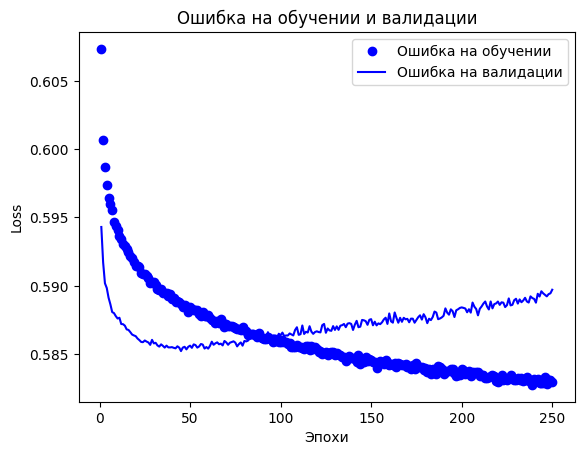

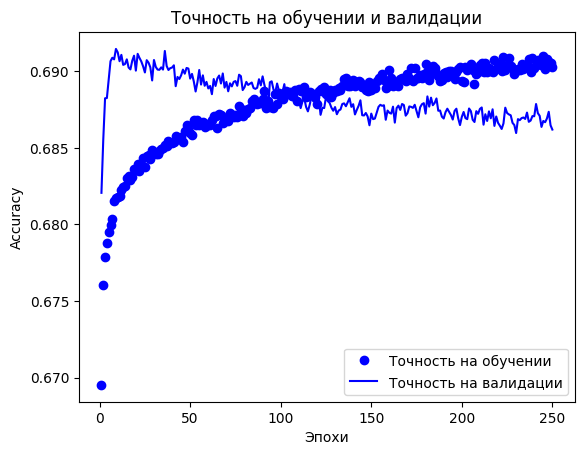

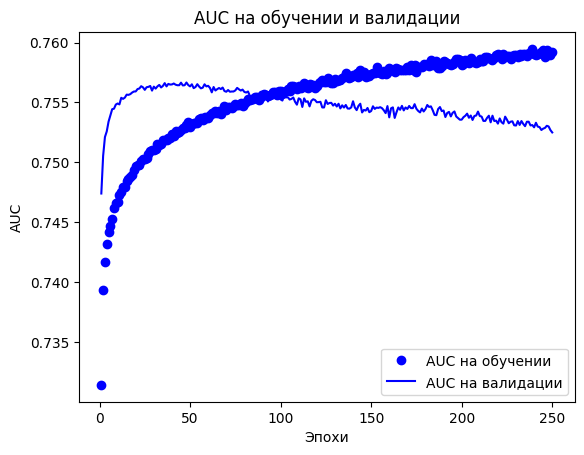

In [44]:
def plot_training_history(history) -> None:
    """Строит графики обучения и валидации для текущей модели."""

    history_dict = history.history
    epochs = range(1, len(history_dict["loss"]) + 1)

    # График ошибки: показывает, как меняется loss на обучении и валидации.
    plt.plot(epochs, history_dict["loss"], "bo", label="Ошибка на обучении")
    plt.plot(epochs, history_dict["val_loss"], "b", label="Ошибка на валидации")
    plt.title("Ошибка на обучении и валидации")
    plt.xlabel("Эпохи")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # График точности: показывает долю правильных ответов для Target1.
    if "accuracy" in history_dict and "val_accuracy" in history_dict:
        plt.clf()
        plt.plot(epochs, history_dict["accuracy"], "bo", label="Точность на обучении")
        plt.plot(epochs, history_dict["val_accuracy"], "b", label="Точность на валидации")
        plt.title("Точность на обучении и валидации")
        plt.xlabel("Эпохи")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()

    # График AUC: полезен для бинарной классификации, особенно если классы несбалансированы.
    if "auc" in history_dict and "val_auc" in history_dict:
        plt.clf()
        plt.plot(epochs, history_dict["auc"], "bo", label="AUC на обучении")
        plt.plot(epochs, history_dict["val_auc"], "b", label="AUC на валидации")
        plt.title("AUC на обучении и валидации")
        plt.xlabel("Эпохи")
        plt.ylabel("AUC")
        plt.legend()
        plt.show()


history = main()
plot_training_history(history)